# 🔗 KAVACH — URL Phishing Detector
### Model 1 of 2 | XGBoost Classifier | 16 Hand-Engineered Features
Train a phishing URL detector that powers KAVACH's real-time link scanning.


## Environment (run once per machine)
Apple Silicon (M1/M2/M3) works natively. Python **3.11+** recommended.

```bash
pip install numpy pandas scikit-learn xgboost matplotlib seaborn joblib tldextract tqdm ipywidgets
```

Use a **venv** or conda env. Restart the kernel after installing packages.

The first run of **tldextract** may download the public suffix list (one-time; needs network).


In [1]:
import os, re, sys, random, string, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import tldextract
from urllib.parse import urlparse, parse_qs
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
plt.style.use("dark_background")
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
print("Imports done")


Imports done


## Step 1 — Feature Engineering
16 signals extracted from each URL. No external API calls needed.


In [2]:
def levenshtein(s1: str, s2: str) -> int:
    """Edit distance between two strings using DP. No external library."""
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev, dp[0] = dp[0], i
        for j in range(1, n + 1):
            temp = dp[j]
            dp[j] = prev if s1[i-1] == s2[j-1] else 1 + min(prev, dp[j], dp[j-1])
            prev = temp
    return dp[n]

assert levenshtein("sbi", "sbi") == 0
assert levenshtein("sbi-kyc", "sbi") == 4
print("Levenshtein OK:", levenshtein("onlinesbi.sbi", "sbi-kyc-update.xyz"))


Levenshtein OK: 17


In [3]:
SUSPICIOUS_TLDS = {
    '.xyz', '.top', '.click', '.pw', '.tk', '.ml', '.ga',
    '.cf', '.gq', '.loan', '.work', '.men', '.download',
    '.stream', '.racing', '.win', '.bid', '.faith', '.party'
}

LEGITIMATE_SBI = {
    'onlinesbi.sbi', 'sbi.co.in', 'retail.onlinesbi.com',
    'sbicard.com', 'sbimf.com', 'sbigeneral.in'
}

SBI_KEYWORDS = ['sbi', 'yono', 'onlinesbi', 'sbionline', 'sbiyono', 'sbibank']

FEATURE_NAMES = [
    'url_length', 'domain_length', 'num_dots', 'num_hyphens',
    'num_underscores', 'num_slashes', 'num_query_params',
    'has_ip_address', 'has_at_symbol', 'has_double_slash',
    'uses_https', 'has_port', 'num_subdomains',
    'levenshtein_to_sbi', 'suspicious_tld', 'has_sbi_keyword'
]
print(len(FEATURE_NAMES), "features defined")


16 features defined


In [4]:
def extract_features(url: str) -> dict:
    url = str(url).strip()
    try:
        parsed = urlparse(url if "://" in url else "http://" + url)
        ext = tldextract.extract(url if "://" in url else "http://" + url)
        domain = (parsed.netloc or ext.fqdn or "").lower()
        scheme = (parsed.scheme or "http").lower()
        query = parsed.query or ""
        registered = ext.registered_domain.lower() if ext.registered_domain else ''
        subdomain = ext.subdomain.lower() if ext.subdomain else ''
        suffix = ('.' + ext.suffix) if ext.suffix else ''
        after_scheme = url[len(scheme)+3:] if scheme and url.lower().startswith(scheme + "://") else url
        is_legit = registered in LEGITIMATE_SBI
        ip_pat = re.compile(r'^(\d{1,3}\.){3}\d{1,3}$')
        host_no_port = domain.split(':')[0]
        return {
            'url_length':        len(url),
            'domain_length':     len(domain),
            'num_dots':          url.count('.'),
            'num_hyphens':       url.count('-'),
            'num_underscores':   url.count('_'),
            'num_slashes':       after_scheme.count('/'),
            'num_query_params':  len(parse_qs(query)) if query else 0,
            'has_ip_address':    1 if ip_pat.match(host_no_port) else 0,
            'has_at_symbol':     1 if '@' in url else 0,
            'has_double_slash':  1 if '//' in after_scheme else 0,
            'uses_https':        1 if scheme == 'https' else 0,
            'has_port':          1 if parsed.port else 0,
            'num_subdomains':    len([p for p in subdomain.split('.') if p]) if subdomain else 0,
            'levenshtein_to_sbi': 0 if is_legit else levenshtein(registered, 'onlinesbi.sbi'),
            'suspicious_tld':    1 if suffix in SUSPICIOUS_TLDS else 0,
            'has_sbi_keyword':   1 if (any(k in url.lower() for k in SBI_KEYWORDS) and not is_legit) else 0,
        }
    except Exception:
        return {k: 0 for k in FEATURE_NAMES}

test = extract_features("http://sbi-kyc-update.xyz/login?id=123456")
print("Phishing URL features (sample):")
for k, v in test.items():
    flag = "  <---" if k in ('suspicious_tld','has_sbi_keyword') and v==1 else ""
    print(f"  {k:<28} {v}{flag}")


Phishing URL features (sample):
  url_length                   41
  domain_length                18
  num_dots                     1
  num_hyphens                  2
  num_underscores              0
  num_slashes                  1
  num_query_params             1
  has_ip_address               0
  has_at_symbol                0
  has_double_slash             0
  uses_https                   0
  has_port                     0
  num_subdomains               0
  levenshtein_to_sbi           17
  suspicious_tld               1  <---
  has_sbi_keyword              1  <---


## Step 2 — Load dataset
Uses `data/phishing_site_urls.csv` in this folder (URL + Label).  
The file is large; we **stratify-sample** so the notebook finishes in a few minutes. Increase `MAX_ROWS` if you want more data.  
After labeling, the next cell **adds a few clean benign URLs** and optionally **balances classes (50/50)** so the model does not treat normal sites like Google as phishing — **re-run training** after changing those flags.


In [5]:
CSV_PATH = os.path.join(DATA_DIR, "phishing_site_urls.csv")
MAX_ROWS = 40_000  # raise to e.g. 150_000 for more data (slower feature pass)

if not os.path.isfile(CSV_PATH):
    raise FileNotFoundError(
        f"Missing {CSV_PATH}. Place phishing_site_urls.csv under ./data/"
    )

raw_df = pd.read_csv(CSV_PATH)
if len(raw_df) > MAX_ROWS:
    raw_df, _ = train_test_split(
        raw_df, train_size=MAX_ROWS, stratify=raw_df["Label"], random_state=42
    )
    raw_df = raw_df.reset_index(drop=True)
print("Loaded rows:", f"{len(raw_df):,}")


Loaded rows: 40,000


In [6]:
df = raw_df.copy()
for col in list(df.columns):
    lc = col.lower()
    if lc == "url" or "url" in lc:
        df = df.rename(columns={col: "URL"})
    if "label" in lc or lc == "class":
        df = df.rename(columns={col: "Label"})

if "URL" not in df.columns or "Label" not in df.columns:
    raise ValueError("Expected URL and Label columns after rename. Got: " + str(list(df.columns)))

df["label"] = df["Label"].apply(
    lambda x: 1 if str(x).strip().lower() in ("bad", "phishing", "1", "malicious") else 0
)

# --- Generalize / fix calibration: "good" rows in CSV are often weird URLs; add clean benign anchors ---
SEED_BENIGN_URLS = [
    "https://www.google.com/",
    "https://www.wikipedia.org/",
    "https://github.com/",
    "https://www.microsoft.com/",
    "https://www.apple.com/",
    "https://www.mozilla.org/",
    "https://www.bbc.com/news",
    "https://www.reddit.com/",
]
BALANCE_CLASSES = True  # 50/50 phishing vs safe (recommended; turn off to match raw CSV ratio)

if SEED_BENIGN_URLS:
    seed_df = pd.DataFrame({"URL": SEED_BENIGN_URLS, "Label": ["good"] * len(SEED_BENIGN_URLS)})
    seed_df["label"] = 0
    df = pd.concat([df, seed_df], ignore_index=True)

if BALANCE_CLASSES:
    ph = df[df["label"] == 1]
    be = df[df["label"] == 0]
    n = min(len(ph), len(be))
    df = pd.concat(
        [ph.sample(n, random_state=42), be.sample(n, random_state=42)],
        ignore_index=True,
    ).sample(frac=1, random_state=43).reset_index(drop=True)
    print(f"Balanced to 50/50: {n:,} phishing + {n:,} safe = {len(df):,} rows")

print(f"Total: {len(df):,}")
print(f"Phishing: {df['label'].sum():,}  ({df['label'].mean()*100:.1f}%)")
print(f"Safe:     {(df['label']==0).sum():,}  ({(df['label']==0).mean()*100:.1f}%)")


Balanced to 50/50: 11,390 phishing + 11,390 safe = 22,780 rows
Total: 22,780
Phishing: 11,390  (50.0%)
Safe:     11,390  (50.0%)


## Step 3 — Extract features
Runs a few minutes on tens of thousands of URLs (URL parsing per row).


In [7]:
try:
    from tqdm.auto import tqdm
except ImportError:
    from tqdm import tqdm

feat_rows = []
labels = []
skipped = 0

for _, row in tqdm(df.iterrows(), total=len(df), desc="Features"):
    try:
        feats = extract_features(str(row["URL"]))
        feat_rows.append([feats[f] for f in FEATURE_NAMES])
        labels.append(int(row["label"]))
    except Exception:
        skipped += 1

X = np.asarray(feat_rows, dtype=float)
y = np.asarray(labels, dtype=int)
print(f"Feature matrix: {X.shape}  |  skipped: {skipped}")


Features:   0%|          | 0/22780 [00:00<?, ?it/s]

Feature matrix: (22780, 16)  |  skipped: 0


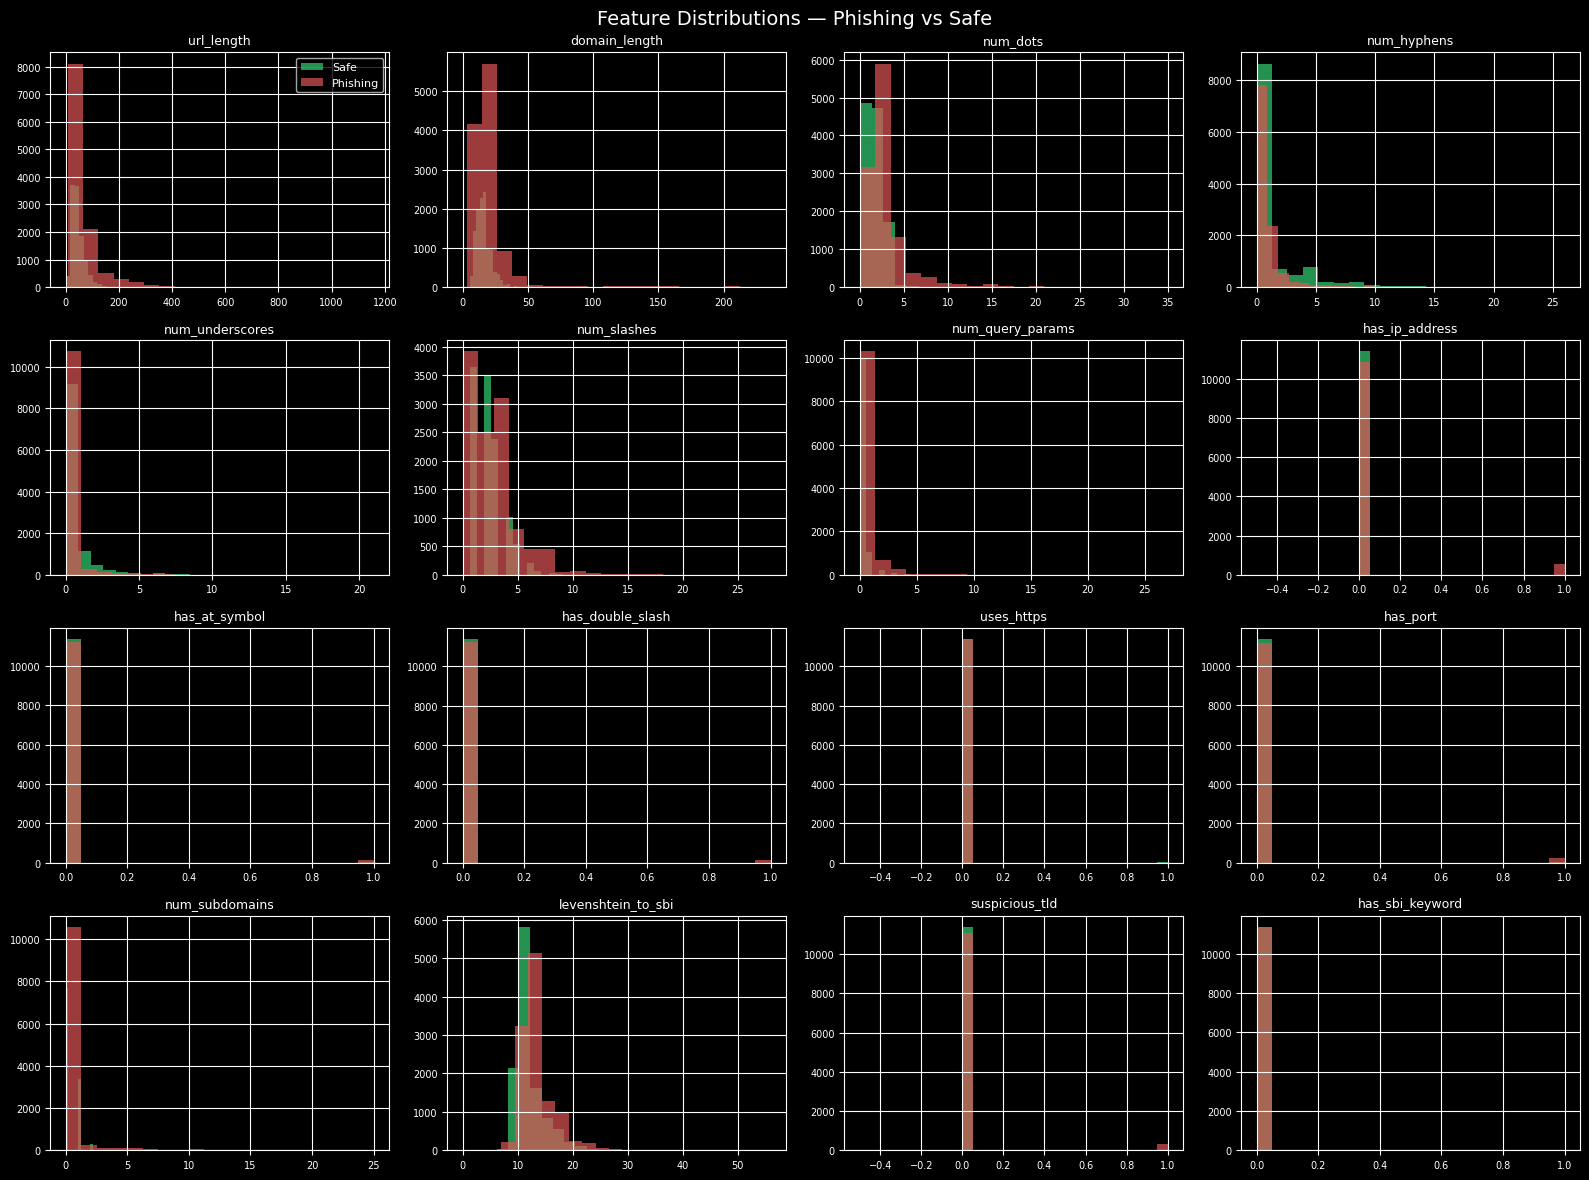

Plot saved to data/feature_distributions.png


In [8]:
feat_df = pd.DataFrame(X, columns=FEATURE_NAMES)
feat_df["label"] = y

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
fig.suptitle("Feature Distributions — Phishing vs Safe", fontsize=14, color="white")
axes = axes.flatten()

for i, feat in enumerate(FEATURE_NAMES):
    ax = axes[i]
    feat_df.loc[feat_df["label"] == 0, feat].hist(ax=ax, bins=20, alpha=0.7, color="#35d073", label="Safe")
    feat_df.loc[feat_df["label"] == 1, feat].hist(ax=ax, bins=20, alpha=0.7, color="#e05555", label="Phishing")
    ax.set_title(feat, fontsize=9, color="white")
    ax.set_xlabel("")
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "feature_distributions.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved to", os.path.join(DATA_DIR, "feature_distributions.png"))


## Step 4 — Train XGBoost model


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
scale = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"scale_pos_weight: {scale:.2f}")


Train: 18,224  |  Test: 4,556
scale_pos_weight: 1.00


In [10]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=float(scale),
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
print("Training complete")


Training complete


## Step 5 — Evaluate


In [11]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=" * 50)
print(classification_report(y_test, y_pred, target_names=["Safe", "Phishing"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("=" * 50)


              precision    recall  f1-score   support

        Safe       0.82      0.85      0.83      2278
    Phishing       0.84      0.82      0.83      2278

    accuracy                           0.83      4556
   macro avg       0.83      0.83      0.83      4556
weighted avg       0.83      0.83      0.83      4556

ROC-AUC Score: 0.9157


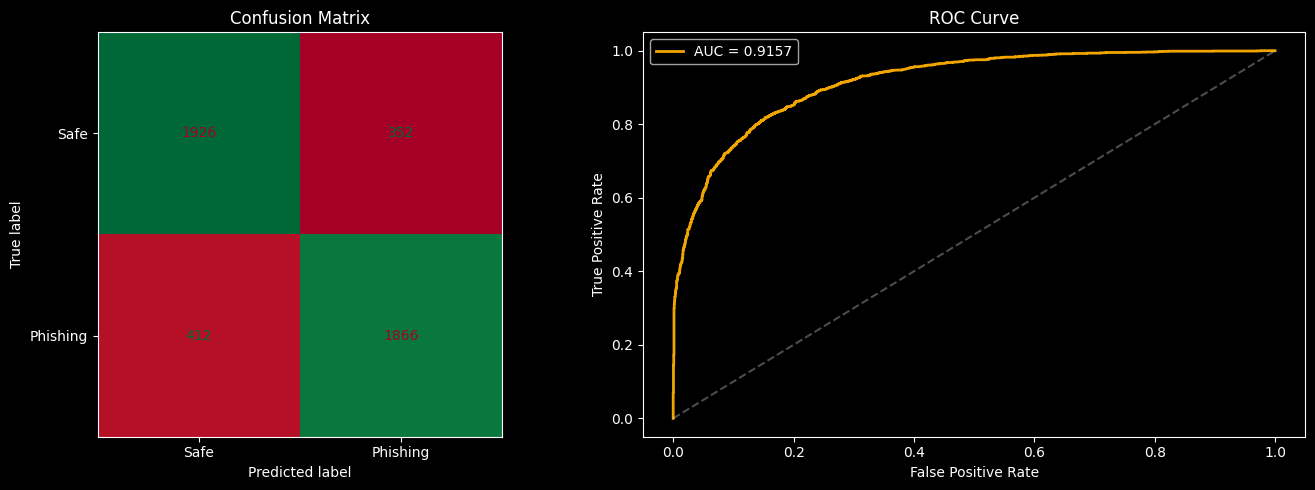

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Safe", "Phishing"]).plot(
    ax=axes[0], colorbar=False, cmap="RdYlGn"
)
axes[0].set_title("Confusion Matrix", color="white")

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#f0a500", lw=2, label=f"AUC = {auc:.4f}")
axes[1].plot([0, 1], [0, 1], "w--", alpha=0.3)
axes[1].set_xlabel("False Positive Rate", color="white")
axes[1].set_ylabel("True Positive Rate", color="white")
axes[1].set_title("ROC Curve", color="white")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "model_evaluation.png"), dpi=120, bbox_inches="tight")
plt.show()


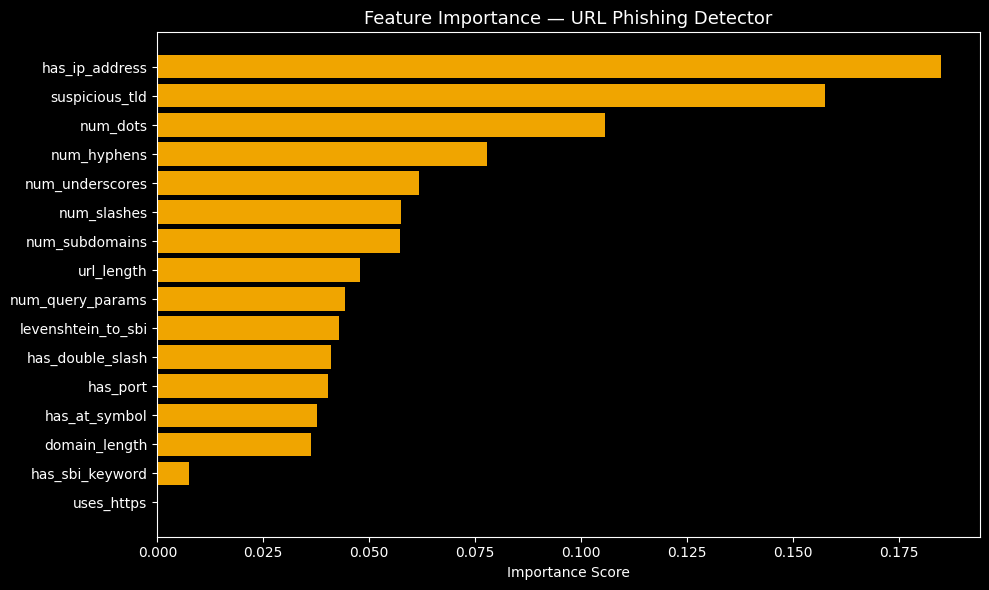

In [13]:
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    [FEATURE_NAMES[i] for i in sorted_idx],
    importances[sorted_idx],
    color="#f0a500",
)
ax.set_xlabel("Importance Score", color="white")
ax.set_title("Feature Importance — URL Phishing Detector", color="white", fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "feature_importance.png"), dpi=120, bbox_inches="tight")
plt.show()


## Step 6 — Save model


In [14]:
model_path = os.path.join(DATA_DIR, "url_model.pkl")
features_path = os.path.join(DATA_DIR, "feature_names.pkl")

joblib.dump(model, model_path)
joblib.dump(FEATURE_NAMES, features_path)

print("Model saved:", model_path)
print("Feature names:", features_path)
print("Model size (KB):", round(os.path.getsize(model_path) / 1024, 1))


Model saved: data/url_model.pkl
Feature names: data/feature_names.pkl
Model size (KB): 864.4


## Step 7 — Quick inference test


In [15]:
def predict_url(url: str) -> None:
    feats = extract_features(url)
    X_in = np.array([[feats[f] for f in FEATURE_NAMES]])
    prob = float(model.predict_proba(X_in)[0, 1])
    verdict = "PHISHING (high risk)" if prob >= 0.65 else "SAFE (low risk)"
    print(f"\n{verdict}  ({prob*100:.1f}% phishing score)")
    print("  URL:", url[:88])

predict_url("http://sbi-kyc-update.xyz/login?id=938472&verify=1")
predict_url("https://www.onlinesbi.sbi/personal/login.htm")
predict_url("http://192.168.1.1/sbi/yono/login")
predict_url("https://www.flipkart.com/offers")



PHISHING (high risk)  (95.3% phishing score)
  URL: http://sbi-kyc-update.xyz/login?id=938472&verify=1

SAFE (low risk)  (15.9% phishing score)
  URL: https://www.onlinesbi.sbi/personal/login.htm

PHISHING (high risk)  (99.9% phishing score)
  URL: http://192.168.1.1/sbi/yono/login

SAFE (low risk)  (41.2% phishing score)
  URL: https://www.flipkart.com/offers


In [16]:
auc = roc_auc_score(y_test, y_prob)
print("\n" + "=" * 55)
print("  KAVACH URL MODEL — TRAINING COMPLETE")
print("=" * 55)
print(f"  Training samples : {len(X_train):,}")
print(f"  Test samples     : {len(X_test):,}")
print(f"  Features used    : {len(FEATURE_NAMES)}")
print(f"  ROC-AUC          : {auc:.4f}")
print(f"  Model saved to   : {model_path}")
print("=" * 55)
print("\n  Next: open train_apk_model.ipynb")



  KAVACH URL MODEL — TRAINING COMPLETE
  Training samples : 18,224
  Test samples     : 4,556
  Features used    : 16
  ROC-AUC          : 0.9157
  Model saved to   : data/url_model.pkl

  Next: open train_apk_model.ipynb
